# Supplemental Results

Per-patient × per-day heatmaps showing engagement, survey response, and event-prompt response across EMU stays.

## Setup

In [14]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from scipy import stats
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch
from dotenv import load_dotenv

from utils.db_connector import get_db_engine

load_dotenv()
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

engine = get_db_engine()

# Cohort roster loaded from the PARTICIPANTS env var (see README for shape)
PARTICIPANTS = json.loads(os.environ.get("PARTICIPANTS"))

users_df       = pd.read_sql("SELECT id, username, status, timezone FROM users", engine)
included_users = users_df[users_df['username'].isin(PARTICIPANTS)].copy()
included_ids   = list(included_users['id'])

# pid_map: user_id -> manuscript_id (used for sorting + y-tick labels)
pid_map = dict(zip(included_users['id'],
                   included_users['username'].map(lambda u: PARTICIPANTS[u]['manuscript_id'])))
# orig_pid_map: user_id -> original PID (used to look up feature flags in PARTICIPANTS)
orig_pid_map = dict(zip(included_users['id'], included_users['username']))
excluded_usernames = sorted(set(users_df['username']) - set(PARTICIPANTS))

def _feat(uid, key):
    """Look up a PARTICIPANTS feature flag for a given user_id."""
    return PARTICIPANTS[orig_pid_map[uid]][key]

# Publication theme (matches publication_results.ipynb)
plt.style.use('ggplot')

# Register the Inter variable font if present (falls back to DejaVu otherwise)
for _f in ['fonts/InterVariable.ttf', 'fonts/InterVariable-Italic.ttf']:
    if os.path.exists(_f):
        fm.fontManager.addfont(_f)
plt.rcParams['font.family']     = ['Inter Variable', 'DejaVu Sans']
plt.rcParams['legend.fontsize'] = 12

BLUE_COLORS = ['#01497c', '#014f86', '#2a6f97', '#2c7da0',
               '#468faf', '#61a5c2', '#89c2d9', '#a9d6e5']
GRAY        = '#E7E7E7'

os.makedirs('plots', exist_ok=True)

def save_both(fig, name):
    """Save figure as PNG (300 dpi) + SVG into ./plots/."""
    fig.savefig(f'plots/{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'plots/{name}.svg', format='svg', bbox_inches='tight')

def save_svg(fig, name):
    """Save figure as SVG only (used for stripped/clean versions)."""
    fig.savefig(f'plots/{name}.svg', format='svg', bbox_inches='tight')

def strip_axes(ax):
    """Apply the stripped-down look: bars + axes + ticks + tick labels only."""
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


## Data loading

Pull user and AI messages for the cohort, derive a `primary_type` per user message, and map each message onto a coarse topic that mirrors the publication's `topic_classification_user_queries` helper:

- `general_chat` / `follow_up_answer` → `general chat`
- `data_agent_seizure` → `seizure`
- `data_agent_spike`   → `spike`
- `data_agent_sleep`   → `sleep`


In [15]:
user_msgs = pd.read_sql(
    "SELECT id, user_id, content, timestamp, message_type, is_moderated, moderated_info "
    "FROM user_messages WHERE user_id = ANY(%(uids)s)",
    engine, params={'uids': included_ids},
)
user_msgs['timestamp'] = pd.to_datetime(user_msgs['timestamp'], utc=True)

def primary_type(arr):
    """Reduce the message_type array to a single label, preferring data_agent_* tags."""
    if arr is None or len(arr) == 0:
        return 'untyped'
    types = list(arr)
    for t in ['data_agent_seizure', 'data_agent_spike', 'data_agent_sleep']:
        if t in types:
            return t
    return types[0]

user_msgs['primary_type'] = user_msgs['message_type'].apply(primary_type)

# Drop the early-cohort follow-ups that have no message_type tag (mirrors the publication helper)
n_untyped_dropped = int((user_msgs['primary_type'] == 'untyped').sum())
user_msgs = user_msgs[user_msgs['primary_type'] != 'untyped'].copy()

# Sanity check vs. publication mapping (each tag in the message_type array is counted independently)
_pub_check = {'seizure': 0, 'sleep': 0, 'spike': 0, 'general chat': 0}
for arr in user_msgs['message_type']:
    if arr is None:
        continue
    for t in list(arr):
        topic = {
            'general_chat':       'general chat',
            'follow_up_answer':   'general chat',
            'data_agent_seizure': 'seizure',
            'data_agent_spike':   'spike',
            'data_agent_sleep':   'sleep',
        }.get(t)
        if topic:
            _pub_check[topic] += 1

# Primary-topic column used by the heatmaps below
TYPE_TO_TOPIC = {
    'general_chat':       'general chat',
    'follow_up_answer':   'general chat',
    'data_agent_seizure': 'seizure',
    'data_agent_spike':   'spike',
    'data_agent_sleep':   'sleep',
}
user_msgs['topic_primary'] = user_msgs['primary_type'].map(TYPE_TO_TOPIC).fillna('other')


In [16]:
ai_msgs = pd.read_sql(
    "SELECT id, user_id, content, timestamp, message_type FROM ai_messages WHERE user_id = ANY(%(uids)s)",
    engine, params={'uids': included_ids},
)
ai_msgs['timestamp'] = pd.to_datetime(ai_msgs['timestamp'], utc=True)


## Per-patient enrollment anchor

Estimate each patient's enrollment timestamp as the earliest of (first survey sent, first user message, first AI message). Day numbers in the heatmaps below are computed in the patient's local timezone, with Day 1 = calendar day of enrollment.

In [17]:
first_user_msg = user_msgs.groupby('user_id')['timestamp'].min().rename('first_user_msg')
first_ai_msg   = ai_msgs.groupby('user_id')['timestamp'].min().rename('first_ai_msg')

surveys_all = pd.read_sql(
    "SELECT user_id, sent_at FROM surveys WHERE user_id = ANY(%(uids)s)",
    engine, params={'uids': included_ids},
)
surveys_all['sent_at'] = pd.to_datetime(surveys_all['sent_at'], utc=True)
first_survey = surveys_all.groupby('user_id')['sent_at'].min().rename('first_survey')

anchors = pd.concat([first_user_msg, first_ai_msg, first_survey], axis=1)
anchors['enroll_ts'] = anchors.min(axis=1)
anchors = anchors.merge(
    included_users[['id', 'timezone']].rename(columns={'id': 'user_id'}).set_index('user_id'),
    left_index=True, right_index=True, how='left',
)
anchors['timezone'] = anchors['timezone'].fillna('America/New_York')

def participation_day(row, ts):
    """Day index (1-based) relative to enrollment in the patient's local timezone."""
    if pd.isna(ts) or pd.isna(row['enroll_ts']):
        return np.nan
    tz = row['timezone']
    enroll_local = row['enroll_ts'].tz_convert(tz)
    ts_local     = ts.tz_convert(tz)
    return (ts_local.normalize() - enroll_local.normalize()).days + 1

def attach_day(df, ts_col):
    df = df.merge(anchors[['enroll_ts', 'timezone']], left_on='user_id', right_index=True, how='left')
    df['day'] = df.apply(lambda r: participation_day(r, r[ts_col]), axis=1)
    return df

user_msgs_d = attach_day(user_msgs, 'timestamp')


## Per-patient LLM engagement (per day)

Four-panel heatmap — one per query topic (`general chat`, `seizure`, `sleep`, `spike`) — of message counts per patient × per day. Cells are grayed out when the feature was unavailable for that patient or after the patient was discharged.

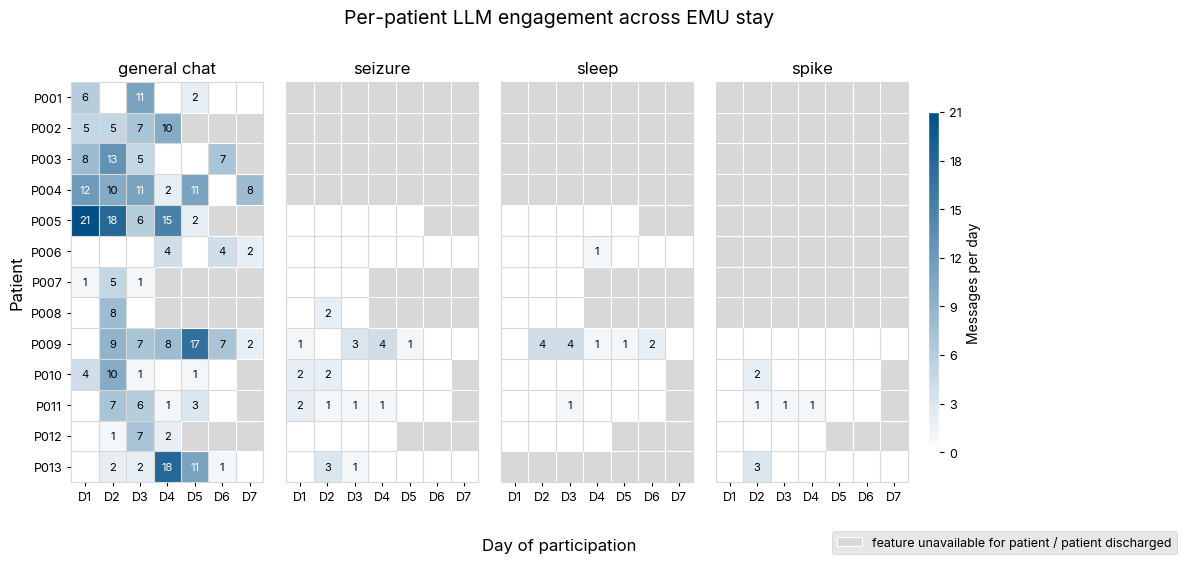

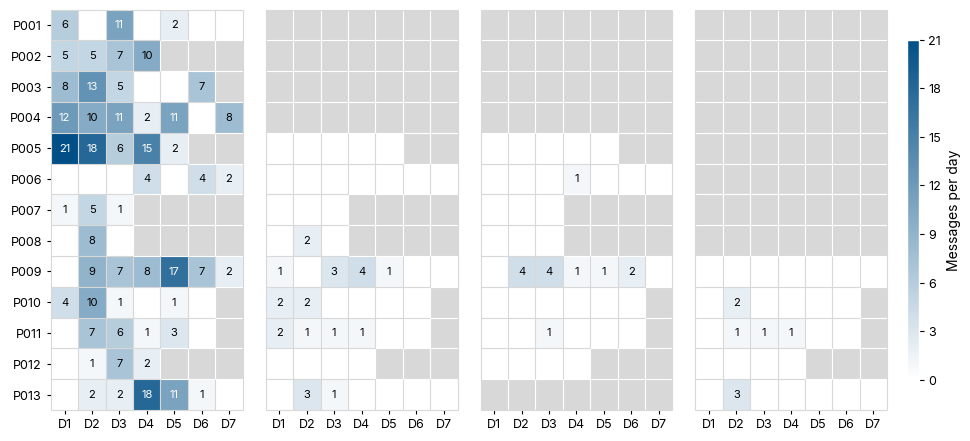

In [18]:
def patient_topic_grid(topic):
    """Build a [patient × day(1..7)] message-count grid for the requested topic."""
    if topic == 'general chat':
        sub = user_msgs_d[user_msgs_d['primary_type'].isin(['general_chat', 'follow_up_answer'])]
    else:
        # Publication mapping: each data_agent_* tag counted independently
        tag = {'seizure': 'data_agent_seizure',
               'spike':   'data_agent_spike',
               'sleep':   'data_agent_sleep'}[topic]
        sub = user_msgs_d[user_msgs_d['message_type'].apply(
            lambda a: a is not None and tag in list(a))]
    sub = sub.dropna(subset=['day']).copy()
    sub['day'] = sub['day'].astype(int)
    sub = sub[(sub['day'] >= 1) & (sub['day'] <= 7)]
    g = sub.groupby(['user_id', 'day']).size().unstack('day', fill_value=0)
    return g.reindex(columns=range(1, 8), fill_value=0)

panels = ['general chat', 'seizure', 'sleep', 'spike']
grids  = {t: patient_topic_grid(t) for t in panels}

# Patient ordering: by manuscript PID (P001, P002, ...)
patients   = sorted(included_ids, key=lambda u: pid_map[u])
pid_labels = [f'P{pid_map[u]}' for u in patients]
for t in panels:
    grids[t] = grids[t].reindex(index=patients, fill_value=0)

# Per-topic feature availability per patient
feature_for = {
    'general chat': {uid: True for uid in patients},
    'seizure':      {uid: _feat(uid, 'data_agent') and _feat(uid, 'seizure') for uid in patients},
    'sleep':        {uid: _feat(uid, 'data_agent') and _feat(uid, 'sleep')   for uid in patients},
    'spike':        {uid: _feat(uid, 'data_agent') and _feat(uid, 'spike')   for uid in patients},
}

# Last day of participation per patient (proxy for discharge)
def _attach_day_series(df, ts_col):
    if df.empty:
        return pd.Series(dtype=int)
    d = df.merge(anchors[['enroll_ts', 'timezone']], left_on='user_id', right_index=True, how='left')
    d['day'] = d.apply(lambda r: participation_day(r, r[ts_col]), axis=1)
    return d.dropna(subset=['day']).groupby('user_id')['day'].max().astype(int)

ai_msgs_for_day = ai_msgs.copy()
last_day_per_pt = pd.concat([
    _attach_day_series(user_msgs, 'timestamp'),
    _attach_day_series(ai_msgs_for_day, 'timestamp'),
    _attach_day_series(surveys_all, 'sent_at'),
    _attach_day_series(sz_events.rename(columns={'notification_sent_at': 'ts'}).assign(ts=lambda d: d['ts']), 'ts') if 'sz_events' in dir() else pd.Series(dtype=int),
    _attach_day_series(sp_events.rename(columns={'notification_sent_at': 'ts'}).assign(ts=lambda d: d['ts']), 'ts') if 'sp_events' in dir() else pd.Series(dtype=int),
], axis=1).max(axis=1).clip(upper=7).fillna(7).astype(int)

# Shared colormap: white → blue with gray "under" for unavailable cells
cmap = LinearSegmentedColormap.from_list('blues_pub', ['#FFFFFF', BLUE_COLORS[1]]).copy()
cmap.set_under('#D8D8D8')
vmax = max(int(g.values.max()) for g in grids.values())
norm = Normalize(vmin=0, vmax=vmax)

def _draw_heatmaps(axes, full=True):
    for j, topic in enumerate(panels):
        ax = axes[j]
        data = grids[topic].values.astype(float)

        # plot_data: -1 = gray (unavailable/discharged), 0 = white, >0 = blue
        mask = np.zeros_like(data, dtype=bool)
        plot_data = data.copy()
        for r, uid in enumerate(patients):
            last_day = int(last_day_per_pt.get(uid, 7))
            enabled  = feature_for[topic].get(uid, False)
            for c in range(data.shape[1]):
                if not enabled or (c + 1) > last_day:
                    mask[r, c] = True
                    plot_data[r, c] = -1

        X = np.arange(8) - 0.5
        Y = np.arange(len(patients) + 1) - 0.5
        rows, cols = data.shape
        im = ax.pcolor(X, Y, plot_data, cmap=cmap, norm=norm, edgecolor='none', snap=True)

        # Cell borders: gray between data cells, white into gray (unavailable) cells
        white_lines, gray_lines = [], []
        for r in range(rows):
            for c in range(cols - 1):
                if plot_data[r, c] >= 0 and plot_data[r, c + 1] >= 0:
                    gray_lines.append([(c + 0.5, r - 0.5), (c + 0.5, r + 0.5)])
                else:
                    white_lines.append([(c + 0.5, r - 0.5), (c + 0.5, r + 0.5)])
        for r in range(rows - 1):
            for c in range(cols):
                if plot_data[r, c] >= 0 and plot_data[r + 1, c] >= 0:
                    gray_lines.append([(c - 0.5, r + 0.5), (c + 0.5, r + 0.5)])
                else:
                    white_lines.append([(c - 0.5, r + 0.5), (c + 0.5, r + 0.5)])
        # Outer border
        gray_lines.append([(-0.5, -0.5), (cols - 0.5, -0.5)])
        gray_lines.append([(-0.5, rows - 0.5), (cols - 0.5, rows - 0.5)])
        gray_lines.append([(-0.5, -0.5), (-0.5, rows - 0.5)])
        gray_lines.append([(cols - 0.5, -0.5), (cols - 0.5, rows - 0.5)])
        ax.add_collection(LineCollection(white_lines, colors='white',   linewidths=0.8, zorder=2, clip_on=False))
        ax.add_collection(LineCollection(gray_lines,  colors='#D8D8D8', linewidths=0.8, zorder=2, clip_on=False))

        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(rows - 0.5, -0.5)
        ax.set_aspect('auto')
        ax.set_xticks(range(7))
        ax.set_xticklabels([f'D{d}' for d in range(1, 8)], fontsize=9, color='#000000')
        ax.set_yticks(range(len(patients)))
        if j == 0:
            ax.set_yticklabels(pid_labels, fontsize=9, fontweight='bold', color='#000000')
        else:
            ax.set_yticklabels([])

        # In-cell numeric labels (skip unavailable / zero cells)
        for r in range(rows):
            for c in range(cols):
                if not mask[r, c] and data[r, c] > 0:
                    v = int(data[r, c])
                    txt_color = 'white' if v / max(vmax, 1) > 0.5 else '#000000'
                    ax.text(c, r, v, ha='center', va='center', fontsize=8, fontweight='bold', color=txt_color)

        if full:
            ax.set_title(topic, fontsize=12, fontweight='bold', pad=6, color='#000000')

        ax.grid(False)
        for s in ax.spines: ax.spines[s].set_visible(False)
        ax.tick_params(axis='x', which='both', length=3, width=0.8, color='#000000', labelcolor='#000000')
        if j == 0:
            ax.tick_params(axis='y', which='both', length=3, width=0.8, color='#000000', labelcolor='#000000', left=True)
        else:
            ax.tick_params(axis='y', which='both', left=False)
    return im

def _attach_colorbar(fig, im, axes_list):
    cbar = fig.colorbar(im, ax=axes_list, shrink=0.85, pad=0.02, aspect=30)
    cbar.set_ticks(np.arange(0, vmax + 1, 3))
    cbar.set_label('Messages per day', fontsize=10, fontweight='bold', color='#000000')
    cbar.ax.tick_params(labelsize=9, labelcolor='#000000', color='#000000')
    return cbar

# Labeled version
fig, axes = plt.subplots(1, 4, figsize=(13, 5.2), sharey=False, gridspec_kw={'wspace': 0.12})
im = _draw_heatmaps(axes, full=True)
fig.suptitle('Per-patient LLM engagement across EMU stay',
             fontsize=14, fontweight='bold', y=1.02, color='#000000')
axes[0].set_ylabel('Patient', fontsize=12, fontweight='bold', color='#000000')
fig.text(0.5, -0.02, 'Day of participation', ha='center', fontsize=12, fontweight='bold', color='#000000')
_attach_colorbar(fig, im, list(axes))
leg = fig.legend(handles=[Patch(facecolor='#D8D8D8', edgecolor='white', linewidth=0.8,
                                label='feature unavailable for patient / patient discharged')],
                 loc='lower right', bbox_to_anchor=(0.98, -0.04),
                 fontsize=9, framealpha=0.9, frameon=True)
for t in leg.get_texts(): t.set_color('#000000')
save_both(fig, 'llm_engagement_trajectory_per_patient')
plt.show()

# Clean version (no titles/labels/legend)
fig_c, axes_c = plt.subplots(1, 4, figsize=(13, 5.2), sharey=False, gridspec_kw={'wspace': 0.12})
im_c = _draw_heatmaps(axes_c, full=False)
_attach_colorbar(fig_c, im_c, list(axes_c))
save_svg(fig_c, 'llm_engagement_trajectory_per_patient_clean')
plt.show()


## Per-patient survey response (per day)

Same patient × day grid, one panel per survey window (morning, afternoon, evening). Cells are shaded if the survey was **completed** that day; sent-but-missed surveys are left white; days with no survey delivered (pre-enrollment or post-discharge) are grayed out.

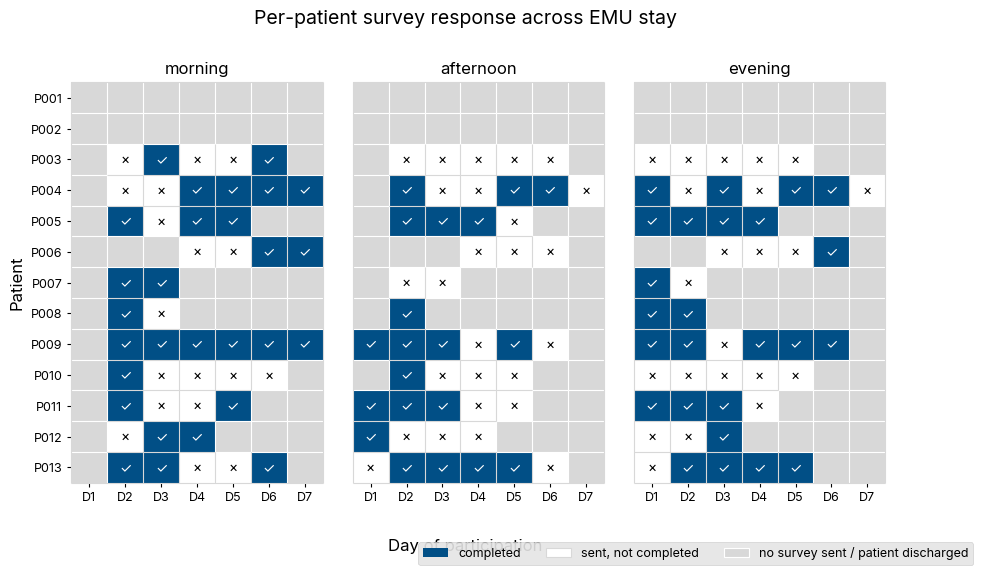

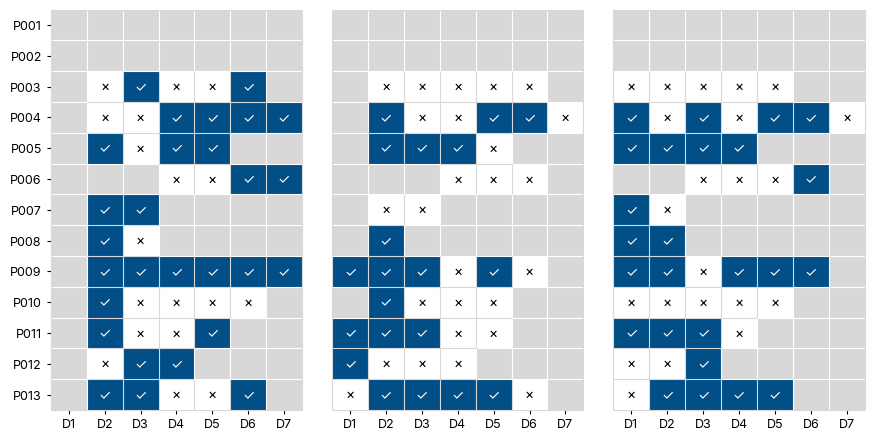

In [19]:
# Pull every morning/afternoon/evening survey for the cohort
surveys_full = pd.read_sql(
    """SELECT id, user_id, survey_type, sent_at, is_completed
       FROM surveys
       WHERE user_id = ANY(%(uids)s)
         AND survey_type IN ('morning', 'afternoon', 'evening')""",
    engine, params={'uids': included_ids},
)
surveys_full['sent_at'] = pd.to_datetime(surveys_full['sent_at'], utc=True)
surveys_full_d = attach_day(surveys_full, 'sent_at')

survey_panels = ['morning', 'afternoon', 'evening']

def survey_grid(stype):
    """Return (sent, completed) grids of shape [patient × day(1..7)] for one survey window."""
    sub = surveys_full_d[surveys_full_d['survey_type'] == stype].dropna(subset=['day']).copy()
    sub['day'] = sub['day'].astype(int)
    sub = sub[(sub['day'] >= 1) & (sub['day'] <= 7)]
    g_sent = (sub.groupby(['user_id', 'day']).size().unstack('day', fill_value=0)
                 .reindex(index=patients, columns=range(1, 8), fill_value=0))
    g_done = (sub[sub['is_completed'] == True]
              .groupby(['user_id', 'day']).size().unstack('day', fill_value=0)
              .reindex(index=patients, columns=range(1, 8), fill_value=0))
    return g_sent, g_done

survey_grids = {s: survey_grid(s) for s in survey_panels}

# Shared cmap (matches engagement heatmap)
cmap_sv = LinearSegmentedColormap.from_list('blues_pub', ['#FFFFFF', BLUE_COLORS[1]]).copy()
cmap_sv.set_under('#D8D8D8')
norm_sv = Normalize(vmin=0, vmax=1)

def _draw_survey_heatmaps(axes, full=True):
    for j, stype in enumerate(survey_panels):
        ax = axes[j]
        sent, done = survey_grids[stype]
        data = done.values.astype(float)  # binary: completed (1) or not (0)
        rows, cols = data.shape

        # plot_data: -1 = gray (no survey sent / post-discharge), 0 = white (missed), 1 = blue (completed)
        mask = np.zeros_like(data, dtype=bool)
        plot_data = data.copy()
        for r, uid in enumerate(patients):
            last_day = int(last_day_per_pt.get(uid, 7))
            for c in range(cols):
                if (c + 1) > last_day or sent.iat[r, c] == 0:
                    mask[r, c] = True
                    plot_data[r, c] = -1

        X = np.arange(cols + 1) - 0.5
        Y = np.arange(rows + 1) - 0.5
        im = ax.pcolor(X, Y, plot_data, cmap=cmap_sv, norm=norm_sv, edgecolor='none', snap=True)

        # Cell borders (same logic as engagement heatmap)
        white_lines, gray_lines = [], []
        for r in range(rows):
            for c in range(cols - 1):
                if plot_data[r, c] >= 0 and plot_data[r, c + 1] >= 0:
                    gray_lines.append([(c + 0.5, r - 0.5), (c + 0.5, r + 0.5)])
                else:
                    white_lines.append([(c + 0.5, r - 0.5), (c + 0.5, r + 0.5)])
        for r in range(rows - 1):
            for c in range(cols):
                if plot_data[r, c] >= 0 and plot_data[r + 1, c] >= 0:
                    gray_lines.append([(c - 0.5, r + 0.5), (c + 0.5, r + 0.5)])
                else:
                    white_lines.append([(c - 0.5, r + 0.5), (c + 0.5, r + 0.5)])
        gray_lines.append([(-0.5, -0.5), (cols - 0.5, -0.5)])
        gray_lines.append([(-0.5, rows - 0.5), (cols - 0.5, rows - 0.5)])
        gray_lines.append([(-0.5, -0.5), (-0.5, rows - 0.5)])
        gray_lines.append([(cols - 0.5, -0.5), (cols - 0.5, rows - 0.5)])
        ax.add_collection(LineCollection(white_lines, colors='white',   linewidths=0.8, zorder=2, clip_on=False))
        ax.add_collection(LineCollection(gray_lines,  colors='#D8D8D8', linewidths=0.8, zorder=2, clip_on=False))

        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(rows - 0.5, -0.5)
        ax.set_aspect('auto')
        ax.set_xticks(range(7))
        ax.set_xticklabels([f'D{d}' for d in range(1, 8)], fontsize=9, color='#000000')
        ax.set_yticks(range(len(patients)))
        if j == 0:
            ax.set_yticklabels(pid_labels, fontsize=9, fontweight='bold', color='#000000')
        else:
            ax.set_yticklabels([])

        # Cell glyphs (kept in both full and clean variants for legibility)
        for r in range(rows):
            for c in range(cols):
                if mask[r, c]:
                    continue
                glyph = '✓' if data[r, c] == 1 else '×'
                color = 'white' if data[r, c] == 1 else '#000000'
                ax.text(c, r, glyph, ha='center', va='center', fontsize=10, fontweight='bold', color=color)

        if full:
            ax.set_title(stype, fontsize=12, fontweight='bold', pad=6, color='#000000')

        ax.grid(False)
        for s in ax.spines: ax.spines[s].set_visible(False)
        ax.tick_params(axis='x', which='both', length=3, width=0.8, color='#000000', labelcolor='#000000')
        if j == 0:
            ax.tick_params(axis='y', which='both', length=3, width=0.8, color='#000000', labelcolor='#000000', left=True)
        else:
            ax.tick_params(axis='y', which='both', left=False)
    return im

# Labeled
fig, axes = plt.subplots(1, 3, figsize=(10.5, 5.2), sharey=False, gridspec_kw={'wspace': 0.12})
_draw_survey_heatmaps(axes, full=True)
fig.suptitle('Per-patient survey response across EMU stay',
             fontsize=14, fontweight='bold', y=1.02, color='#000000')
axes[0].set_ylabel('Patient', fontsize=12, fontweight='bold', color='#000000')
fig.text(0.5, -0.02, 'Day of participation', ha='center', fontsize=12, fontweight='bold', color='#000000')
leg = fig.legend(handles=[
    Patch(facecolor=BLUE_COLORS[1], edgecolor='none', label='completed'),
    Patch(facecolor='#FFFFFF', edgecolor='#D8D8D8', linewidth=0.8, label='sent, not completed'),
    Patch(facecolor='#D8D8D8', edgecolor='white',   linewidth=0.8, label='no survey sent / patient discharged'),
], loc='lower right', bbox_to_anchor=(0.99, -0.06), fontsize=9, framealpha=0.9, frameon=True, ncol=3)
for t in leg.get_texts(): t.set_color('#000000')
save_both(fig, 'per_patient_survey_response')
plt.show()

# Clean (drops titles/labels/legend; keeps ticks + glyphs)
fig_c, axes_c = plt.subplots(1, 3, figsize=(10.5, 5.2), sharey=False, gridspec_kw={'wspace': 0.12})
_draw_survey_heatmaps(axes_c, full=False)
save_svg(fig_c, 'per_patient_survey_response_clean')
plt.show()


## Per-patient event-prompt response (per day)

Two panels: **seizure prompts** and **spike prompts** delivered to the patient, with cell color encoding the response **rate** that day (0 = no responses, 1 = every prompt answered). Annotations show `responded/delivered`. Days with no prompt delivered, or where the feature wasn't available / the patient was already discharged, are grayed out.

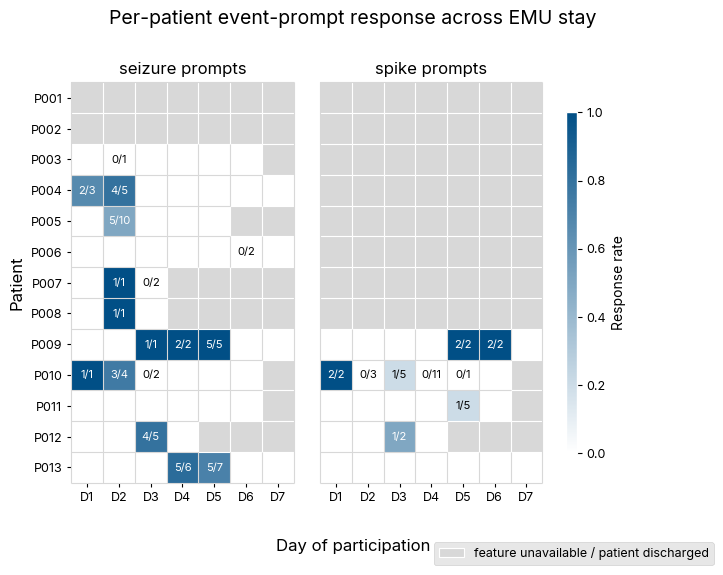

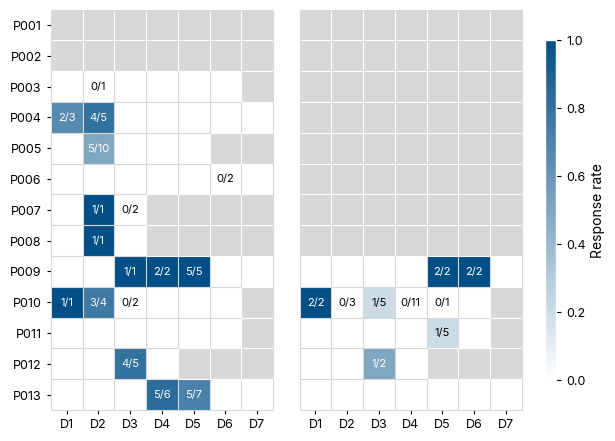

In [20]:
# Seizure prompt grids
sz_events_pp = pd.read_sql(
    'SELECT id, user_id, notification_sent_at FROM seizure_events '
    'WHERE notification_sent_at IS NOT NULL AND user_id = ANY(%(uids)s)',
    engine, params={'uids': included_ids},
)
sz_events_pp['notification_sent_at'] = pd.to_datetime(sz_events_pp['notification_sent_at'], utc=True)
sz_ann_pp = pd.read_sql('SELECT seizure_event_id, classified_response FROM seizure_annotations', engine)
sz_pp = sz_events_pp.merge(sz_ann_pp, left_on='id', right_on='seizure_event_id', how='left')
sz_pp['responded'] = sz_pp['classified_response'].notna()

# Spike prompt grids
sp_events_pp = pd.read_sql(
    'SELECT id, user_id, notification_sent_at FROM spike_events '
    'WHERE notification_sent_at IS NOT NULL AND user_id = ANY(%(uids)s)',
    engine, params={'uids': included_ids},
)
sp_events_pp['notification_sent_at'] = pd.to_datetime(sp_events_pp['notification_sent_at'], utc=True)
sp_ann_pp = pd.read_sql('SELECT spike_event_id, raw_response FROM spike_annotations', engine)
sp_pp = sp_events_pp.merge(sp_ann_pp, left_on='id', right_on='spike_event_id', how='left')
sp_pp['responded'] = sp_pp['raw_response'].notna()

def event_grid(df, label):
    df = attach_day(df, 'notification_sent_at').dropna(subset=['day']).copy()
    df['day'] = df['day'].astype(int)
    df = df[(df['day'] >= 1) & (df['day'] <= 7)]
    sent = (df.groupby(['user_id', 'day']).size().unstack('day', fill_value=0)
              .reindex(index=patients, columns=range(1, 8), fill_value=0))
    done = (df[df['responded']].groupby(['user_id', 'day']).size().unstack('day', fill_value=0)
              .reindex(index=patients, columns=range(1, 8), fill_value=0))
    return sent, done

event_panels = ['seizure', 'spike']
event_grids = {
    'seizure': event_grid(sz_pp, 'seizure'),
    'spike':   event_grid(sp_pp, 'spike'),
}

# Manual overrides: remove the responses excluded from the publication (duplicate events for P003, P005, P013)
for uid in patients:
    pid = str(pid_map[uid])
    if pid in ['003', '3']:
        event_grids['seizure'][1].at[uid, 2] = max(0, event_grids['seizure'][1].at[uid, 2] - 1)
    if pid in ['005', '5']:
        event_grids['seizure'][1].at[uid, 2] = max(0, event_grids['seizure'][1].at[uid, 2] - 1)
    if pid in ['013', '13']:
        event_grids['seizure'][0].at[uid, 5] = max(0, event_grids['seizure'][0].at[uid, 5] - 1)
        event_grids['seizure'][1].at[uid, 5] = max(0, event_grids['seizure'][1].at[uid, 5] - 1)

# Event prompts gate on the monitoring feature only (not the data_agent flag)
event_feature = {
    'seizure': {uid: _feat(uid, 'seizure') for uid in patients},
    'spike':   {uid: _feat(uid, 'spike')   for uid in patients},
}

cmap_ev = LinearSegmentedColormap.from_list('blues_pub', ['#FFFFFF', BLUE_COLORS[1]]).copy()
cmap_ev.set_under('#D8D8D8')
norm_ev = Normalize(vmin=0, vmax=1)

def _draw_event_heatmaps(axes, full=True):
    for j, etype in enumerate(event_panels):
        ax = axes[j]
        sent, done = event_grids[etype]
        with np.errstate(divide='ignore', invalid='ignore'):
            rate = np.where(sent.values > 0, done.values / sent.values, 0.0)
        rows, cols = rate.shape

        # plot_data: -1 = gray, 0 = white (sent but no responses), else rate in [0,1]
        plot_data = np.zeros_like(rate, dtype=float)
        for r, uid in enumerate(patients):
            last_day    = int(last_day_per_pt.get(uid, 7))
            feature_on  = event_feature[etype].get(uid, False)
            for c in range(cols):
                if (not feature_on) or (c + 1) > last_day:
                    plot_data[r, c] = -1
                elif sent.iat[r, c] == 0:
                    plot_data[r, c] = 0
                else:
                    plot_data[r, c] = rate[r, c]

        X = np.arange(cols + 1) - 0.5
        Y = np.arange(rows + 1) - 0.5
        im = ax.pcolor(X, Y, plot_data, cmap=cmap_ev, norm=norm_ev, edgecolor='none', snap=True)

        white_lines, gray_lines = [], []
        for r in range(rows):
            for c in range(cols - 1):
                if plot_data[r, c] >= 0 and plot_data[r, c + 1] >= 0:
                    gray_lines.append([(c + 0.5, r - 0.5), (c + 0.5, r + 0.5)])
                else:
                    white_lines.append([(c + 0.5, r - 0.5), (c + 0.5, r + 0.5)])
        for r in range(rows - 1):
            for c in range(cols):
                if plot_data[r, c] >= 0 and plot_data[r + 1, c] >= 0:
                    gray_lines.append([(c - 0.5, r + 0.5), (c + 0.5, r + 0.5)])
                else:
                    white_lines.append([(c - 0.5, r + 0.5), (c + 0.5, r + 0.5)])
        gray_lines.append([(-0.5, -0.5), (cols - 0.5, -0.5)])
        gray_lines.append([(-0.5, rows - 0.5), (cols - 0.5, rows - 0.5)])
        gray_lines.append([(-0.5, -0.5), (-0.5, rows - 0.5)])
        gray_lines.append([(cols - 0.5, -0.5), (cols - 0.5, rows - 0.5)])
        ax.add_collection(LineCollection(white_lines, colors='white',   linewidths=0.8, zorder=2, clip_on=False))
        ax.add_collection(LineCollection(gray_lines,  colors='#D8D8D8', linewidths=0.8, zorder=2, clip_on=False))

        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(rows - 0.5, -0.5)
        ax.set_aspect('auto')
        ax.set_xticks(range(7))
        ax.set_xticklabels([f'D{d}' for d in range(1, 8)], fontsize=9, color='#000000')
        ax.set_yticks(range(len(patients)))
        if j == 0:
            ax.set_yticklabels(pid_labels, fontsize=9, fontweight='bold', color='#000000')
        else:
            ax.set_yticklabels([])

        # Annotate cells with "responded/sent"
        for r in range(rows):
            for c in range(cols):
                if plot_data[r, c] >= 0 and sent.iat[r, c] > 0:
                    k = int(done.iat[r, c]); n = int(sent.iat[r, c])
                    txt_color = 'white' if rate[r, c] > 0.4 else '#000000'
                    ax.text(c, r, f'{k}/{n}', ha='center', va='center', fontsize=8, fontweight='bold', color=txt_color)

        if full:
            ax.set_title(f'{etype} prompts', fontsize=12, fontweight='bold', pad=6, color='#000000')

        ax.grid(False)
        for s in ax.spines: ax.spines[s].set_visible(False)
        ax.tick_params(axis='x', which='both', length=3, width=0.8, color='#000000', labelcolor='#000000')
        if j == 0:
            ax.tick_params(axis='y', which='both', length=3, width=0.8, color='#000000', labelcolor='#000000', left=True)
        else:
            ax.tick_params(axis='y', which='both', left=False)
    return im

def _attach_event_colorbar(fig, im, axes_list):
    cbar = fig.colorbar(im, ax=axes_list, shrink=0.85, pad=0.04, aspect=30)
    cbar.set_label('Response rate', fontsize=10, fontweight='bold', color='#000000')
    cbar.ax.tick_params(labelsize=9, labelcolor='#000000', color='#000000')
    return cbar

# Labeled
fig, axes = plt.subplots(1, 2, figsize=(7.5, 5.2), sharey=False, gridspec_kw={'wspace': 0.12})
im = _draw_event_heatmaps(axes, full=True)
fig.suptitle('Per-patient event-prompt response across EMU stay',
             fontsize=14, fontweight='bold', y=1.02, color='#000000')
axes[0].set_ylabel('Patient', fontsize=12, fontweight='bold', color='#000000')
fig.text(0.5, -0.02, 'Day of participation', ha='center', fontsize=12, fontweight='bold', color='#000000')
_attach_event_colorbar(fig, im, list(axes))
leg = fig.legend(handles=[Patch(facecolor='#D8D8D8', edgecolor='white', linewidth=0.8,
                                label='feature unavailable / patient discharged')],
                 loc='lower right', bbox_to_anchor=(0.99, -0.06),
                 fontsize=9, framealpha=0.9, frameon=True)
for t in leg.get_texts(): t.set_color('#000000')
save_both(fig, 'per_patient_event_response')
plt.show()

# Clean
fig_c, axes_c = plt.subplots(1, 2, figsize=(7.5, 5.2), sharey=False, gridspec_kw={'wspace': 0.12})
im_c = _draw_event_heatmaps(axes_c, full=False)
_attach_event_colorbar(fig_c, im_c, list(axes_c))
save_svg(fig_c, 'per_patient_event_response_clean')
plt.show()
